# Relative Rotation Graph

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import warnings
warnings.filterwarnings('ignore')

In [32]:
class SectorRRGAnalyzer:
    """
    Sector-focused Relative Rotation Graph (RRG) Generator
    Monitor entire sectors using ETFs and indices
    """
    
    def __init__(self, sectors_dict, benchmark='SPY', start_date='2023-01-01', end_date=None):
        """
        Initialize sector RRG analyzer
        
        Parameters:
        sectors_dict: Dictionary with sector names as keys and ticker symbols as values
        benchmark: benchmark ETF/index for relative comparison
        """
        self.sectors = sectors_dict
        self.symbols = list(sectors_dict.values())
        self.sector_names = list(sectors_dict.keys())
        self.benchmark = benchmark
        self.start_date = start_date
        self.end_date = end_date or pd.Timestamp.now().strftime('%Y-%m-%d')
        self.data = None
        self.relative_prices = None
        self.rs_ratios = None
        self.rs_momentum = None
        
    def fetch_data(self):
        """Fetch price data from Yahoo Finance"""
        print(f"Fetching sector data from {self.start_date} to {self.end_date}...")
        
        # Add benchmark to symbols list
        all_symbols = self.symbols + [self.benchmark]
        
        # Download data
        data = yf.download(all_symbols, start=self.start_date, end=self.end_date, auto_adjust=True)['Close']
        
        # Handle potential missing data
        data = data.dropna(axis=1, how='all')
        self.data = data
        
        print(f"Downloaded data for {len(data.columns)} securities")
        return self.data
    
    def calculate_rrg_metrics(self, lookback=26, smoothing=1):
        """
        Calculate RRG metrics (RS-Ratio and RS-Momentum)
        
        RS-Ratio = (Price/Benchmark) / 52-week moving average of that ratio * 100
        RS-Momentum = (Current RS-Ratio / RS-Ratio 4 weeks ago) * 100
        """
        if self.data is None:
            self.fetch_data()
        
        # Calculate relative prices (sector ETF / benchmark)
        benchmark_data = self.data[self.benchmark]
        self.relative_prices = self.data[self.symbols].div(benchmark_data, axis=0)
        
        # Use weekly data to smooth noise
        weekly_data = self.relative_prices.resample('W').last()
        
        # Calculate RS-Ratio: (current relative price / 52-week MA of relative price) * 100
        weekly_ma = weekly_data.rolling(window=lookback, min_periods=20).mean()
        self.rs_ratios = (weekly_data / weekly_ma) * 100
        
        # Optional smoothing of RS-Ratio before momentum calculation
        rs_ratio_smoothed = self.rs_ratios.rolling(window=smoothing).mean()
        
        # RS-Momentum: (current RS-Ratio / RS-Ratio 4 weeks ago) * 100
        self.rs_momentum = (rs_ratio_smoothed / rs_ratio_smoothed.shift(4)) * 100
        
        return self.rs_ratios, self.rs_momentum
    
    def plot_sector_rrg(self, figsize=(14, 10)):
        """Generate RRG plot for sectors"""
        current_ratios, current_momentum = self.get_current_positions()
        
        # Create mapping from symbols to sector names
        symbol_to_sector = dict(zip(self.symbols, self.sector_names))
        
        fig, ax = plt.subplots(figsize=figsize)
        
        # Draw quadrants
        ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
        ax.axvline(x=100, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
        
        # Draw reference circles
        circle100 = Circle((100, 100), 5, fill=False, linestyle=':', color='gray', alpha=0.3)
        ax.add_patch(circle100)
        circle105 = Circle((100, 100), 10, fill=False, linestyle=':', color='gray', alpha=0.2)
        ax.add_patch(circle105)
        
        # Color quadrants with light transparency
        ax.axhspan(100, max(current_momentum.max(), 105), facecolor='#90EE90', alpha=0.1)
        ax.axhspan(min(current_momentum.min(), 95), 100, facecolor='#FFB6C1', alpha=0.1)
        
        # Define colors for different sectors
        colors = plt.cm.Set3(np.linspace(0, 1, len(self.symbols)))
        
        # Plot points with sector names
        for i, (symbol, color) in enumerate(zip(self.symbols, colors)):
            x = current_ratios[symbol]
            y = current_momentum[symbol]
            sector_name = symbol_to_sector[symbol]
            
            # Plot point
            ax.scatter(x, y, c=[color], s=300, alpha=0.8, 
                      edgecolors='black', linewidth=2, zorder=5)
            
            # Add sector name label
            ax.annotate(sector_name, (x, y), xytext=(8, 8), 
                       textcoords='offset points', fontsize=10, fontweight='bold',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        # Configure axes
        ax.set_xlabel('RS-Ratio (Relative Strength vs S&P 500)', fontsize=12, fontweight='bold')
        ax.set_ylabel('RS-Momentum (Momentum)', fontsize=12, fontweight='bold')
        ax.set_title('Sector Rotation - Relative Rotation Graph (RRG)', 
                    fontsize=16, fontweight='bold', pad=20)
        
        # Set limits with padding
        x_margin = max(3, (current_ratios.max() - current_ratios.min()) * 0.15)
        y_margin = max(3, (current_momentum.max() - current_momentum.min()) * 0.15)
        
        ax.set_xlim(current_ratios.min() - x_margin, current_ratios.max() + x_margin)
        ax.set_ylim(current_momentum.min() - y_margin, current_momentum.max() + y_margin)
        
        # Enhanced quadrant labels
        ax.text(103, 103, 'LEADING', fontsize=14, fontweight='bold', 
               color='darkgreen', ha='left', va='bottom')
        ax.text(103, 97, 'WEAKENING', fontsize=14, fontweight='bold', 
               color='darkorange', ha='left', va='top')
        ax.text(97, 97, 'LAGGING', fontsize=14, fontweight='bold', 
               color='darkred', ha='right', va='top')
        ax.text(97, 103, 'IMPROVING', fontsize=14, fontweight='bold', 
               color='darkblue', ha='right', va='bottom')
        
        # Add grid
        ax.grid(True, alpha=0.2, linestyle='--')
        
        # Add timestamp and benchmark info
        current_date = pd.Timestamp.now().strftime('%Y-%m-%d')
        ax.text(0.02, 0.98, f'Data as of: {current_date}\nBenchmark: {self.benchmark}', 
                transform=ax.transAxes, fontsize=9, color='gray',
                verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        return fig, ax
    
    def get_current_positions(self):
        """Get current RS-Ratio and RS-Momentum values"""
        if self.rs_ratios is None or self.rs_momentum is None:
            self.calculate_rrg_metrics()
        
        current_ratios = self.rs_ratios.iloc[-1]
        current_momentum = self.rs_momentum.iloc[-1]
        
        return current_ratios, current_momentum
    
    def print_sector_analysis(self):
        """Print detailed sector analysis"""
        current_ratios, current_momentum = self.get_current_positions()
        symbol_to_sector = dict(zip(self.symbols, self.sector_names))
        
        print("\n" + "="*80)
        print("SECTOR ROTATION ANALYSIS")
        print("="*80)
        
        # Create DataFrame with results
        results = []
        for symbol in self.symbols:
            ratio = current_ratios[symbol]
            momentum = current_momentum[symbol]
            sector = symbol_to_sector[symbol]
            
            # Determine quadrant
            if ratio > 100 and momentum > 100:
                quadrant = "LEADING ★"
                strength = "Strong"
            elif ratio > 100 and momentum < 100:
                quadrant = "WEAKENING ↓"
                strength = "Peaking"
            elif ratio < 100 and momentum < 100:
                quadrant = "LAGGING ●"
                strength = "Weak"
            else:
                quadrant = "IMPROVING ↑"
                strength = "Improving"
            
            results.append({
                'Sector': sector,
                'Ticker': symbol,
                'RS-Ratio': ratio,
                'RS-Momentum': momentum,
                'Quadrant': quadrant,
                'Strength': strength
            })
        
        df = pd.DataFrame(results)
        df = df.sort_values('RS-Ratio', ascending=False)
        
        # Print formatted table
        print("\nSector Rankings by Relative Strength:")
        print("-"*80)
        print(f"{'Sector':<20} {'Ticker':<8} {'RS-Ratio':>10} {'RS-Mom':>10} {'Quadrant':<20}")
        print("-"*80)
        
        for _, row in df.iterrows():
            print(f"{row['Sector']:<20} {row['Ticker']:<8} "
                  f"{row['RS-Ratio']:>10.2f} {row['RS-Momentum']:>10.2f} "
                  f"{row['Quadrant']:<20}")
        
        # Summary statistics
        print("\n" + "="*80)
        print("ROTATION SUMMARY")
        print("="*80)
        
        leading = df[df['Quadrant'].str.contains('LEADING')]
        improving = df[df['Quadrant'].str.contains('IMPROVING')]
        weakening = df[df['Quadrant'].str.contains('WEAKENING')]
        lagging = df[df['Quadrant'].str.contains('LAGGING')]
        
        print(f"Leading Sectors (Q1): {len(leading)} - {', '.join(leading['Sector'].tolist())}")
        print(f"Improving Sectors (Q4): {len(improving)} - {', '.join(improving['Sector'].tolist())}")
        print(f"Weakening Sectors (Q2): {len(weakening)} - {', '.join(weakening['Sector'].tolist())}")
        print(f"Lagging Sectors (Q3): {len(lagging)} - {', '.join(lagging['Sector'].tolist())}")
        
        return df
    
    def plot_rrg_with_trajectories(self, sectors_to_trace=None, weeks=12, figsize=(14, 10)):
        """
        Plot RRG with historical trajectories for selected sectors.
        
        Parameters:
        sectors_to_trace: list of sector names (keys from self.sectors) or tickers to trace.
                        If None, traces all sectors (may be cluttered).
        weeks: number of weeks of history to plot.
        figsize: figure size.
        """
        if self.rs_ratios is None or self.rs_momentum is None:
            self.calculate_rrg_metrics()
        
        # Get current positions
        current_ratios, current_momentum = self.get_current_positions()
        
        # Mapping from sector name to ticker and vice versa
        name_to_ticker = self.sectors
        ticker_to_name = {v: k for k, v in self.sectors.items()}
        
        # Determine which sectors to trace
        trace_sectors = []
        if sectors_to_trace is None:
            # Default: trace all sectors (might be too many, but user can filter)
            trace_sectors = list(self.sectors.keys())
        else:
            trace_sectors = sectors_to_trace
        
        # Convert sector names to tickers if necessary
        trace_tickers = []
        for s in trace_sectors:
            if s in name_to_ticker:
                trace_tickers.append(name_to_ticker[s])
            elif s in ticker_to_name:
                trace_tickers.append(s)  # already a ticker
            else:
                print(f"Warning: {s} not found. Skipping.")
        
        # Create figure
        fig, ax = plt.subplots(figsize=figsize)
        
        # First, gather all data to determine appropriate axis limits
        all_ratios_list = []
        all_momentum_list = []
        
        for ticker in trace_tickers:
            rs_ratio_hist = self.rs_ratios[ticker].iloc[-weeks:]
            rs_momentum_hist = self.rs_momentum[ticker].iloc[-weeks:]
            all_ratios_list.append(rs_ratio_hist)
            all_momentum_list.append(rs_momentum_hist)
        
        # Add current positions for all sectors to ensure they're within limits
        all_ratios_list.append(current_ratios)
        all_momentum_list.append(current_momentum)
        
        all_ratios = pd.concat(all_ratios_list)
        all_momentum = pd.concat(all_momentum_list)
        
        # Calculate limits with padding
        x_min, x_max = all_ratios.min(), all_ratios.max()
        y_min, y_max = all_momentum.min(), all_momentum.max()
        
        # Ensure the center (100,100) is visible
        x_min = min(x_min, 95)
        x_max = max(x_max, 105)
        y_min = min(y_min, 95)
        y_max = max(y_max, 105)
        
        # Add padding
        x_padding = max(5, (x_max - x_min) * 0.1)
        y_padding = max(5, (y_max - y_min) * 0.1)
        
        ax.set_xlim(x_min - x_padding, x_max + x_padding)
        ax.set_ylim(y_min - y_padding, y_max + y_padding)
        
        # Draw quadrants and reference lines
        ax.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
        ax.axvline(x=100, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
        
        # Draw reference circles
        circle100 = Circle((100, 100), 5, fill=False, linestyle=':', color='gray', alpha=0.3)
        ax.add_patch(circle100)
        circle105 = Circle((100, 100), 10, fill=False, linestyle=':', color='gray', alpha=0.2)
        ax.add_patch(circle105)
        
        # Color quadrants with light transparency - using actual axis limits
        ax.axhspan(100, ax.get_ylim()[1], facecolor='#90EE90', alpha=0.1)
        ax.axhspan(ax.get_ylim()[0], 100, facecolor='#FFB6C1', alpha=0.1)
        
        # Plot current positions for all sectors as background (light)
        for ticker in self.symbols:
            if ticker in current_ratios.index and ticker in current_momentum.index:
                x = current_ratios[ticker]
                y = current_momentum[ticker]
                ax.scatter(x, y, c='lightgray', s=100, alpha=0.3, edgecolors='gray', linewidth=1, zorder=2)
        
        # Plot trajectories
        colors = plt.cm.tab20(np.linspace(0, 1, len(trace_tickers)))
        for ticker, color in zip(trace_tickers, colors):
            sector_name = ticker_to_name.get(ticker, ticker)
            
            # Get historical data for this ticker
            rs_ratio_hist = self.rs_ratios[ticker].iloc[-weeks:]
            rs_momentum_hist = self.rs_momentum[ticker].iloc[-weeks:]
            
            # Plot trajectory line
            ax.plot(rs_ratio_hist, rs_momentum_hist, color=color, linewidth=2, alpha=0.7,
                    label=f'{sector_name}')
            
            # Mark start point (oldest) with circle
            ax.scatter(rs_ratio_hist.iloc[0], rs_momentum_hist.iloc[0], 
                    color=color, s=80, marker='o', edgecolors='black', zorder=4)
            
            # Mark end point (current) with square
            ax.scatter(rs_ratio_hist.iloc[-1], rs_momentum_hist.iloc[-1], 
                    color=color, s=150, marker='s', edgecolors='black', zorder=5)
        
        # Highlight traced sectors' current positions with labels
        for ticker, color in zip(trace_tickers, colors):
            if ticker in current_ratios.index and ticker in current_momentum.index:
                x = current_ratios[ticker]
                y = current_momentum[ticker]
                sector_name = ticker_to_name.get(ticker, ticker)
                
                # Plot highlighted point
                ax.scatter(x, y, c=[color], s=300, alpha=0.9, edgecolors='black', linewidth=2, zorder=6)
                
                # Add sector name label - position based on data coordinates
                ax.annotate(sector_name, (x, y), xytext=(8, 8), textcoords='offset points',
                        fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, 
                                    edgecolor=color))
        
        # Configure axes
        ax.set_xlabel('RS-Ratio (Relative Strength vs S&P 500)', fontsize=12, fontweight='bold')
        ax.set_ylabel('RS-Momentum (Momentum)', fontsize=12, fontweight='bold')
        ax.set_title('Sector RRG with Historical Trajectories', fontsize=16, fontweight='bold', pad=20)
        
        # Quadrant labels - positioned relative to the actual axis limits
        x_center = 100
        y_center = 100
        x_limit = ax.get_xlim()
        y_limit = ax.get_ylim()
        
        # Position labels in the corners of each quadrant
        ax.text(x_center + (x_limit[1] - x_center) * 0.1, y_center + (y_limit[1] - y_center) * 0.1, 
                'LEADING', fontsize=12, fontweight='bold', color='darkgreen', 
                ha='left', va='bottom', bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
        
        ax.text(x_center + (x_limit[1] - x_center) * 0.1, y_center - (y_center - y_limit[0]) * 0.1, 
                'WEAKENING', fontsize=12, fontweight='bold', color='darkorange', 
                ha='left', va='top', bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
        
        ax.text(x_center - (x_center - x_limit[0]) * 0.1, y_center - (y_center - y_limit[0]) * 0.1, 
                'LAGGING', fontsize=12, fontweight='bold', color='darkred', 
                ha='right', va='top', bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
        
        ax.text(x_center - (x_center - x_limit[0]) * 0.1, y_center + (y_limit[1] - y_center) * 0.1, 
                'IMPROVING', fontsize=12, fontweight='bold', color='darkblue', 
                ha='right', va='bottom', bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
        
        ax.grid(True, alpha=0.2, linestyle='--')
        
        # Add legend for trajectories (only if we have traced sectors)
        if trace_tickers:
            # Create custom legend handles
            from matplotlib.lines import Line2D
            legend_elements = []
            for ticker, color in zip(trace_tickers, colors):
                sector_name = ticker_to_name.get(ticker, ticker)
                legend_elements.append(Line2D([0], [0], color=color, lw=2, label=sector_name))
            
            # Add start/end markers to legend
            legend_elements.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
                                        markersize=8, label='Start (oldest)'))
            legend_elements.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
                                        markersize=8, label='Current'))
            
            ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1), 
                    fontsize=9, framealpha=0.9)
        
        # Add info text
        current_date = pd.Timestamp.now().strftime('%Y-%m-%d')
        info_text = f'Data as of: {current_date}\nBenchmark: {self.benchmark}\nTrajectory: last {weeks} weeks'
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes, fontsize=9, color='gray',
                verticalalignment='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        return fig, ax

# Comprehensive sector tickers for monitoring
def get_sector_etfs():
    """Return comprehensive dictionary of sector ETFs"""
    return {
        # US Sector ETFs (SPDR Select Sectors)
        'Technology': 'XLK',
        'Financials': 'XLF',
        'Healthcare': 'XLV',
        'Energy': 'XLE',
        'Consumer Discretionary': 'XLY',
        'Consumer Staples': 'XLP',
        'Industrials': 'XLI',
        'Materials': 'XLB',
        'Utilities': 'XLU',
        'Real Estate': 'XLRE',
        'Communication Services': 'XLC',
        
        # Broad Market ETFs
        'S&P 500': 'SPY',  # Benchmark
        'Dow Jones': 'DIA',
        'Nasdaq': 'QQQ',
        'Mid Caps': 'MDY',
        'Small Caps': 'IWM',
        
        # International/Global
        'Developed Markets': 'EFA',
        'Emerging Markets': 'EEM',
        'China': 'FXI',
        'Europe': 'VGK',
        'Japan': 'EWJ',
        
        # Bond Sectors
        'Treasuries': 'TLT',
        'Corporate Bonds': 'LQD',
        'High Yield': 'HYG',
        'Municipal Bonds': 'MUB',
        
        # Commodity Sectors
        'Gold': 'GLD',
        'Silver': 'SLV',
        'Oil': 'USO',
        'Agriculture': 'DBA',
        
        # Thematic Sectors
        'Cybersecurity': 'HACK',
        'Cloud Computing': 'SKYY',
        'Semiconductors': 'SMH',
        'Biotech': 'IBB',
        'Clean Energy': 'ICLN',
        'AI & Robotics': 'BOTZ',
        'Fintech': 'FINX',
        'E-commerce': 'IBUY'
    }

def get_major_sector_etfs():
    """Return major US sector ETFs (11 sectors)"""
    return {
        'Technology': 'XLK',
        'Financials': 'XLF',
        'Healthcare': 'XLV',
        'Energy': 'XLE',
        'Consumer Disc': 'XLY',
        'Consumer Stap': 'XLP',
        'Industrials': 'XLI',
        'Materials': 'XLB',
        'Utilities': 'XLU',
        'Real Estate': 'XLRE',
        'Communication': 'XLC'
    }

def get_global_sector_etfs():
    """Return global sector ETFs"""
    return {
        'US Total Market': 'VTI',
        'Developed Markets': 'VEA',
        'Emerging Markets': 'VWO',
        'Europe': 'VGK',
        'Pacific': 'VPL',
        'China': 'MCHI',
        'India': 'INDA',
        'Brazil': 'EWZ',
        'Japan': 'EWJ',
        'UK': 'EWU'
    }

In [ ]:
def runRRG(choice):
    if choice == '1':
        sectors = get_major_sector_etfs()
        benchmark = 'SPY'  # S&P 500 ETF
        title = "Major US Sectors RRG"
    elif choice == '2':
        sectors = get_sector_etfs()
        benchmark = 'SPY'
        title = "All US Sectors RRG (Including Thematic)"
    elif choice == '3':
        sectors = get_global_sector_etfs()
        benchmark = 'VT'  # Total World Stock ETF
        title = "Global Market Sectors RRG"
    else:
        print("Invalid choice, using major US sectors")
        sectors = get_major_sector_etfs()
        benchmark = 'SPY'

    # Create analyzer
    rrg = SectorRRGAnalyzer(
        sectors_dict=sectors,
        benchmark=benchmark,
        start_date='2024-01-01'
    )

    # Generate RRG plot
    print(f"\nGenerating {title}...")
    # fig, ax = rrg.plot_sector_rrg()
    # plt.show()
    # After creating rrg object
    fig, ax = rrg.plot_rrg_with_trajectories()
    plt.show()

    # Print detailed analysis
    df = rrg.print_sector_analysis()

    # Identify rotation patterns
    print("\n" + "="*80)
    print("ROTATION PATTERNS & TRADING SIGNALS")
    print("="*80)

    # Find sectors moving into leading quadrant
    improving_to_leading = df[(df['Quadrant'].str.contains('IMPROVING')) & 
                                (df['RS-Ratio'] < 100) & 
                                (df['RS-Momentum'] > 100)]

    if not improving_to_leading.empty:
        print("POTENTIAL BREAKOUTS (Moving from Improving to Leading):")
        for _, row in improving_to_leading.iterrows():
            print(f"   • {row['Sector']}: RS-Ratio={row['RS-Ratio']:.1f}, Momentum={row['RS-Momentum']:.1f}")

    # Find sectors weakening
    weakening = df[df['Quadrant'].str.contains('WEAKENING')]
    if not weakening.empty:
        print("WATCH FOR WEAKNESS (May rotate to Lagging):")
        for _, row in weakening.iterrows():
            print(f"   • {row['Sector']}: RS-Ratio={row['RS-Ratio']:.1f}, Momentum={row['RS-Momentum']:.1f}")

    # Find strongest momentum
    top_momentum = df.nlargest(3, 'RS-Momentum')[['Sector', 'RS-Momentum', 'Quadrant']]
    print("STRONGEST MOMENTUM:")
    for _, row in top_momentum.iterrows():
        print(f"   • {row['Sector']}: {row['RS-Momentum']:.1f} ({row['Quadrant']})")

[                       0%                       ]


Generating Major US Sectors RRG...
Fetching sector data from 2024-01-01 to 2026-03-09...


[*********************100%***********************]  12 of 12 completed


Downloaded data for 12 securities


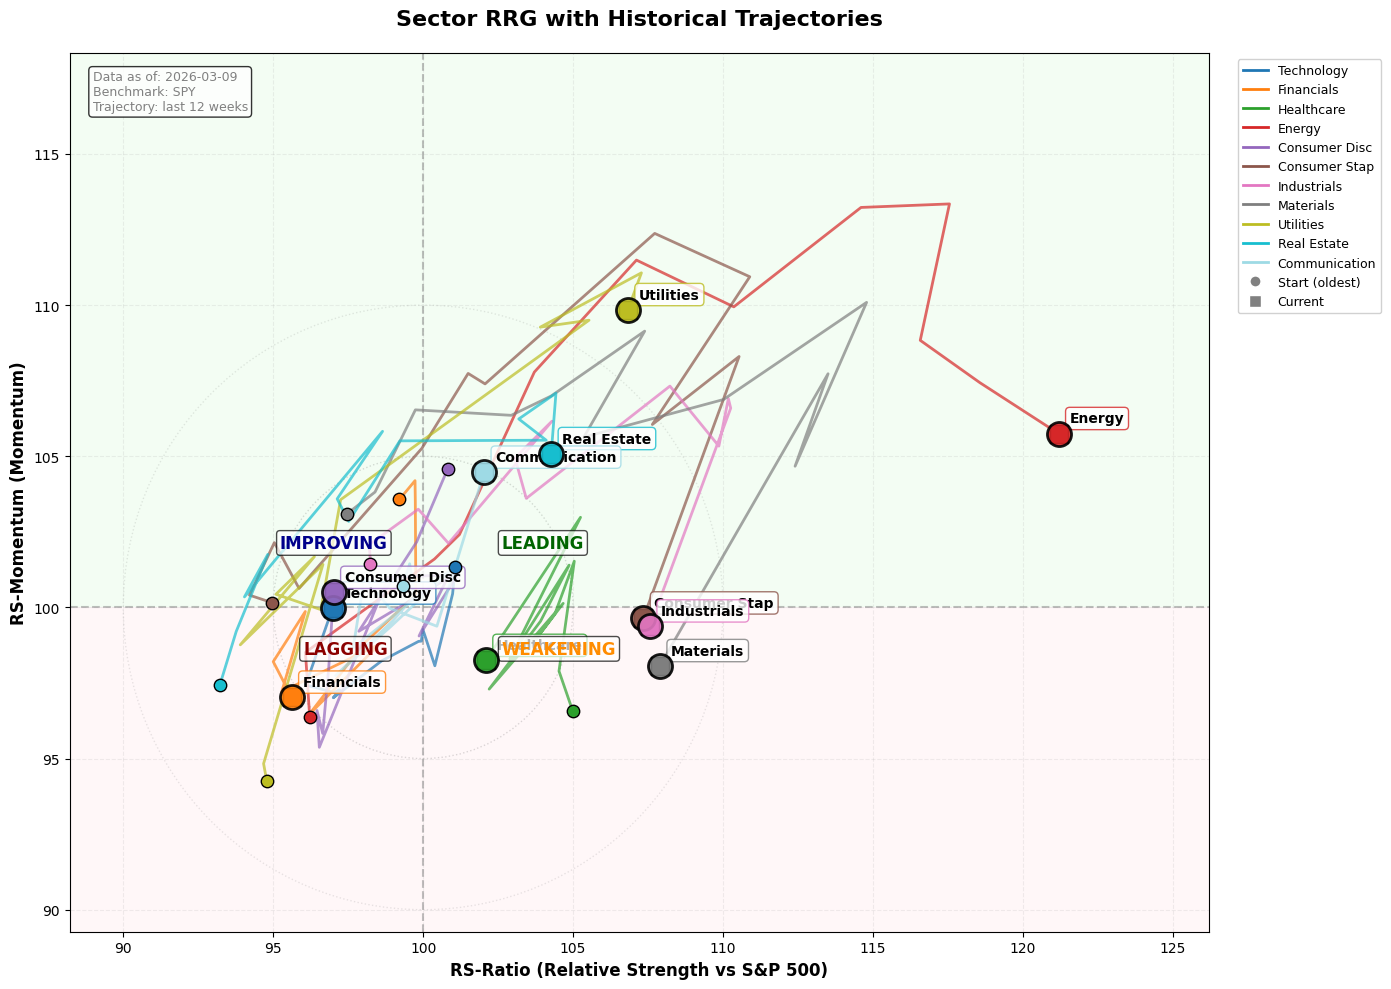


SECTOR ROTATION ANALYSIS

Sector Rankings by Relative Strength:
--------------------------------------------------------------------------------
Sector               Ticker     RS-Ratio     RS-Mom Quadrant            
--------------------------------------------------------------------------------
Energy               XLE          121.19     105.75 LEADING ★           
Materials            XLB          107.90      98.07 WEAKENING ↓         
Industrials          XLI          107.56      99.38 WEAKENING ↓         
Consumer Stap        XLP          107.34      99.65 WEAKENING ↓         
Utilities            XLU          106.83     109.85 LEADING ★           
Real Estate          XLRE         104.27     105.09 LEADING ★           
Healthcare           XLV          102.09      98.24 WEAKENING ↓         
Communication        XLC          102.03     104.47 LEADING ★           
Consumer Disc        XLY           97.02     100.49 IMPROVING ↑         
Technology           XLK           96.98   

In [34]:
choice = '1'
runRRG(choice)